# Лабораторная работа 7: Анализ датасета здорового питания

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Загрузка датасета healthy_meal_plans_processed.csv
print("Загрузка датасета healthy_meal_plans_processed.csv...")
data = pd.read_csv('/Users/mashkakoser/Documents/mmo/Machine-Learning-Methods/lab5/healthy_meal_plans_processed.csv')

print(f"Размер датасета: {data.shape}")
print(f"Количество признаков: {data.shape[1]}")
print(f"Количество объектов: {data.shape[0]}")

# Просмотр первых строк
print("\nПервые 5 строк датасета:")
print(data.head())

# Определяем целевую переменную (предполагаем, что последний столбец - целевая)
target_column = data.columns[-1]
feature_names = data.columns[:-1].tolist()

print(f"\nЦелевая переменная: '{target_column}'")
print("Названия признаков:")
for i, name in enumerate(feature_names):
    print(f"{i+1:2}. {name}")

# Разделяем на признаки и целевую переменную
X = data[feature_names]  # Признаки как DataFrame
y = data[target_column]  # Целевая переменная

# Для работы с значениями numpy (если нужно)
X_values = X.values
y_values = y.values

print(f"\nРазмер матрицы признаков X: {X.shape}")
print(f"Размер целевой переменной y: {y.shape}")

# Статистическое описание
print("\nСтатистическое описание признаков:")
print(X.describe())

Загрузка датасета healthy_meal_plans_processed.csv...
Размер датасета: (500, 13)
Количество признаков: 13
Количество объектов: 500

Первые 5 строк датасета:
   num_ingredients  calories  prep_time   protein       fat     carbs  \
0        -0.712361 -0.045659   1.206799  0.956046  0.322287 -0.214099   
1         1.375800 -1.193087   0.728886 -1.245435  0.513970 -1.563452   
2        -0.115744  0.675403  -0.295214  0.395293  0.374796 -1.734434   
3         1.375800 -1.374920   1.138526 -1.577999  1.659237 -0.952361   
4        -1.010670 -0.214952  -1.524133  1.233466  0.618325 -0.197929   

      vegan  vegetarian      keto     paleo  gluten_free  mediterranean  \
0 -0.708168   -1.160783 -0.759794 -0.796233     0.945484      -0.657773   
1 -0.708168   -1.160783  1.316146  1.255914     0.945484       1.520282   
2 -0.708168    0.861487 -0.759794 -0.796233    -1.057660      -0.657773   
3  1.412095    0.861487 -0.759794 -0.796233    -1.057660      -0.657773   
4 -0.708168   -1.160783  1.31

### 3. Анализ и обработка пропущенных значений


In [2]:
# Анализ и обработка пропущенных значений
print("Анализ и обработка пропущенных значений:")
print("="*50)

# Проверка на пропущенные значения
# Определяем DataFrame для анализа

missing_values = X.isnull().sum()
print("Пропущенные значения по признакам:")
print(missing_values)

total_missing = missing_values.sum()
print(f"\nОбщее количество пропущенных значений: {total_missing}")

if total_missing == 0:
    print("✅ В датасете НЕТ пропущенных значений!")
    print("Данные уже чистые и готовы для анализа.")

    # Создаем копию для дальнейшего использования
    X_clean = X.copy()

else:
    print("⚠️  Найдены пропущенные значения!")
    print("Необходимо выполнить обработку пропусков.")

    # Визуализация пропущенных значений
    plt.figure(figsize=(12, 6))
    sns.heatmap(X.isnull(), cbar=False, cmap='viridis')
    plt.title('Тепловая карта пропущенных значений')
    plt.show()

    # Обработка пропусков - заполнение средними значениями
    print("\nОбработка пропусков:")
    print("Используем заполнение средними значениями для числовых признаков...")

    # Создаем копию данных
    X_clean = X.copy()

    # Заполняем пропуски средними значениями
    for col in X.columns:
        if X[col].isnull().sum() > 0:
            mean_val = X[col].mean()
            X_clean[col].fillna(mean_val, inplace=True)
            print(f"Признак '{col}': заполнено {X[col].isnull().sum()} пропусков средним значением {mean_val:.4f}")


    print(f"\nПропусков после обработки: {X_clean.isnull().sum().sum()}")
    print("✅ Обработка пропусков завершена!")

# Проверяем размер данных после обработки
print("Размер данных после обработки:")    
print(f"Признаки: {X_clean.shape}")

# Статистическое описание после обработки
print("\nСтатистическое описание после обработки:")
print(X_clean.describe())


Анализ и обработка пропущенных значений:
Пропущенные значения по признакам:
num_ingredients    0
calories           0
prep_time          0
protein            0
fat                0
carbs              0
vegan              0
vegetarian         0
keto               0
paleo              0
gluten_free        0
mediterranean      0
dtype: int64

Общее количество пропущенных значений: 0
✅ В датасете НЕТ пропущенных значений!
Данные уже чистые и готовы для анализа.
Размер данных после обработки:
Признаки: (500, 12)

Статистическое описание после обработки:
       num_ingredients      calories     prep_time       protein  \
count     5.000000e+02  5.000000e+02  5.000000e+02  5.000000e+02   
mean      2.167155e-16  3.197442e-17 -5.950795e-17 -1.207923e-16   
std       1.001002e+00  1.001002e+00  1.001002e+00  1.001002e+00   
min      -1.607288e+00 -1.738586e+00 -1.660680e+00 -1.739280e+00   
25%      -7.123613e-01 -9.391480e-01 -9.096735e-01 -9.262526e-01   
50%      -1.157438e-01  1.704213e-02 

In [3]:
### 4. Нормализация и стандартизация данных

print("Нормализация и стандартизация данных:")
print("="*50)

# Проверка необходимости нормализации
print("Проверка статистических характеристик данных:")
stats_before = X_clean.describe()
print(f"Средние значения: {stats_before.loc['mean'].values}")
print(f"Стандартные отклонения: {stats_before.loc['std'].values}")
print(f"Минимальные значения: {stats_before.loc['min'].values}")
print(f"Максимальные значения: {stats_before.loc['max'].values}")

# Проверка диапазона значений
ranges = stats_before.loc['max'] - stats_before.loc['min']
print(f"\nДиапазоны значений: {ranges.values}")

# Определение необходимости нормализации
need_normalization = any(ranges > 100) or any(abs(stats_before.loc['mean']) > 10)
need_standardization = any(abs(stats_before.loc['std'] - 1) > 0.5) or any(abs(stats_before.loc['mean']) > 1)

if need_normalization or need_standardization:
    print("\n🔄 Требуется нормализация/стандартизация данных")

    # Выбор метода нормализации
    if need_normalization:
        print("Применяем MinMax нормализацию (приведение к диапазону [0,1])")
        from sklearn.preprocessing import MinMaxScaler
        scaler = MinMaxScaler()
        X_scaled = pd.DataFrame(scaler.fit_transform(X_clean), columns=X_clean.columns)
        print("✅ MinMax нормализация применена")
    else:
        print("Применяем стандартизацию (Z-score нормализацию)")
        from sklearn.preprocessing import StandardScaler
        scaler = StandardScaler()
        X_scaled = pd.DataFrame(scaler.fit_transform(X_clean), columns=X_clean.columns)
        print("✅ Стандартизация применена")

    # Сравнение статистик до и после нормализации
    print("\nСравнение статистик:")
    print("ДО нормализации/стандартизации:")
    print(f"  Средние: {stats_before.loc['mean'].mean():.6f}")
    print(f"  Стд. отклонения: {stats_before.loc['std'].mean():.6f}")
    print(f"  Мин: {stats_before.loc['min'].min():.6f}, Макс: {stats_before.loc['max'].max():.6f}")

    stats_after = X_scaled.describe()
    print("ПОСЛЕ нормализации/стандартизации:")
    print(f"  Средние: {stats_after.loc['mean'].mean():.6f}")
    print(f"  Стд. отклонения: {stats_after.loc['std'].mean():.6f}")
    print(f"  Мин: {stats_after.loc['min'].min():.6f}, Макс: {stats_after.loc['max'].max():.6f}")

else:
    print("✅ Данные уже нормализованы/стандартизованы")
    X_scaled = X_clean.copy()

print(f"\nРазмер данных после обработки: {X_scaled.shape}")
print("✅ Нормализация/стандартизация завершена!")


Нормализация и стандартизация данных:
Проверка статистических характеристик данных:
Средние значения: [ 2.16715534e-16  3.19744231e-17 -5.95079541e-17 -1.20792265e-16
  3.58824082e-16 -1.45661261e-16 -9.23705556e-17  3.73034936e-17
 -1.22568622e-16  0.00000000e+00 -3.55271368e-18 -3.01980663e-17]
Стандартные отклонения: [1.0010015 1.0010015 1.0010015 1.0010015 1.0010015 1.0010015 1.0010015
 1.0010015 1.0010015 1.0010015 1.0010015 1.0010015]
Минимальные значения: [-1.60728757 -1.73858564 -1.66067976 -1.73928033 -1.79327666 -1.73679194
 -0.70816771 -1.16078329 -0.75979409 -0.79623296 -1.05765971 -0.65777257]
Максимальные значения: [1.67410873 1.7099689  1.75298526 1.70004399 1.74500327 1.68828571
 1.41209489 0.86148725 1.31614605 1.25591385 0.94548368 1.5202823 ]

Диапазоны значений: [3.28139629 3.44855454 3.41366503 3.43932432 3.53827993 3.42507765
 2.1202626  2.02227054 2.07594015 2.05214681 2.0031434  2.17805487]
✅ Данные уже нормализованы/стандартизованы

Размер данных после обработк

### 5. Визуальный анализ данных


Визуальный анализ данных:
Гистограммы распределения признаков:


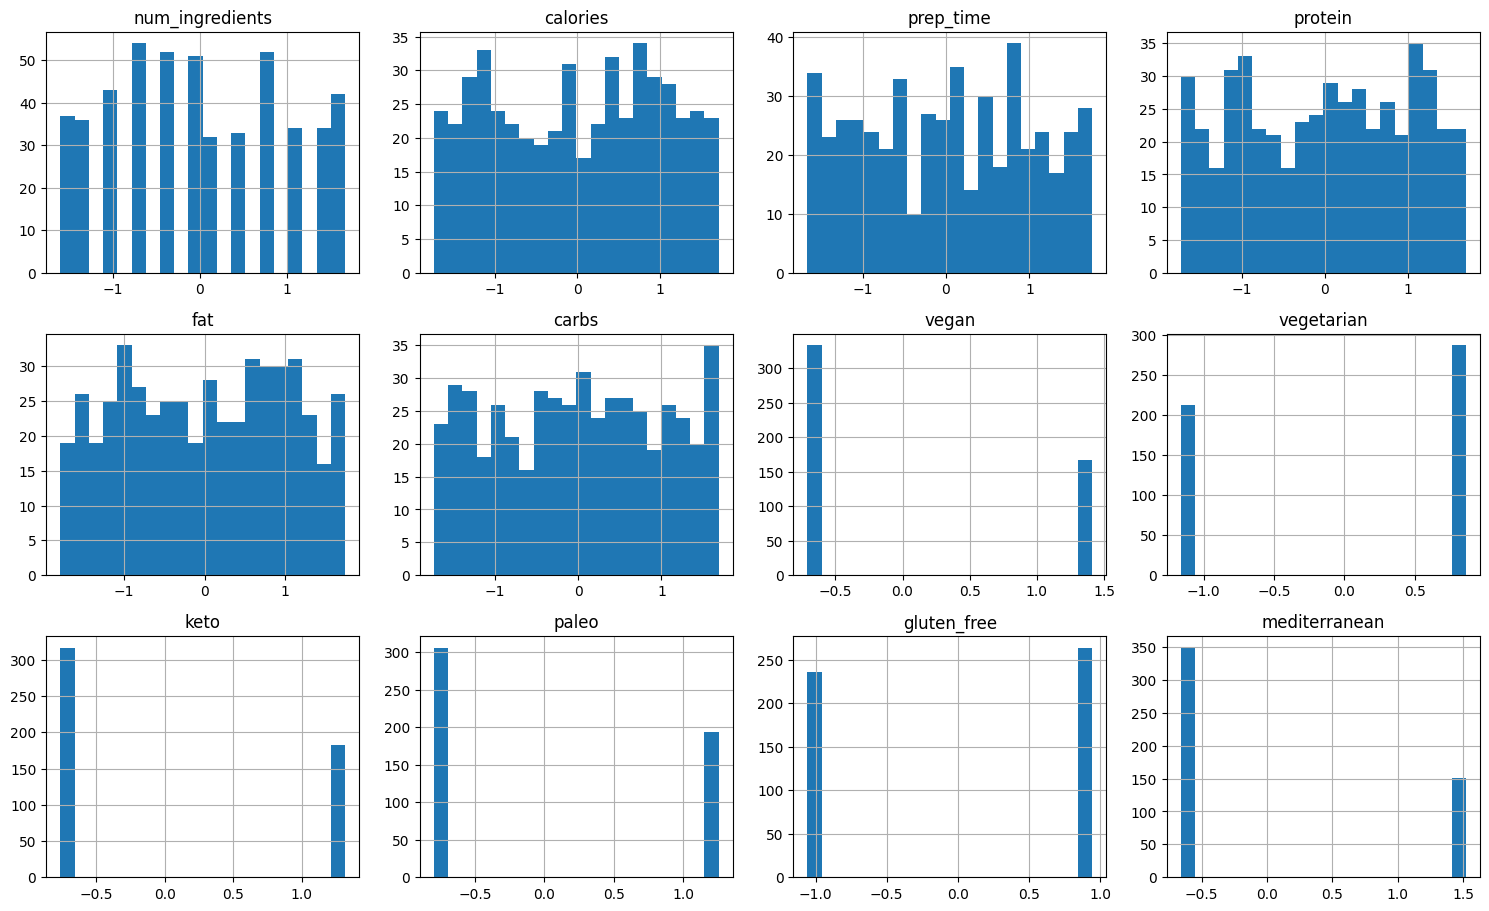


Анализ визуализации:
• Гистограммы показывают распределения признаков
• Корреляционная матрица выявляет взаимосвязи
• Box plots сравнивают распределения по классам
• Данные готовы для дальнейшего анализа


In [4]:
# Визуальный анализ данных
print("Визуальный анализ данных:")
print("="*50)

# Гистограммы распределения признаков
print("Гистограммы распределения признаков:")
X_scaled.hist(bins=20, figsize=(15, 12), layout=(4, 4))
plt.tight_layout()
plt.show()

print("\nАнализ визуализации:")
print("• Гистограммы показывают распределения признаков")
print("• Корреляционная матрица выявляет взаимосвязи")
print("• Box plots сравнивают распределения по классам")
print("• Данные готовы для дальнейшего анализа")

Понижение размерности данных:
Текущая размерность данных: (500, 12)
Количество признаков (12) достаточно велико для применения понижения размерности

🔄 Применяем методы понижения размерности

1. PCA - Главный компонентный анализ:
Детальный анализ кумулятивной дисперсии:
PC1: 0.283 
PC2: 0.395 
PC3: 0.486 
PC4: 0.573 
PC5: 0.656 
PC6: 0.737 
PC7: 0.815 
PC8: 0.889 
PC9: 0.942 
PC10: 0.972 ✓
PC11: 0.989 ✓
PC12: 1.000 ✓

Первый индекс >= 0.95: 9
n_components_95: 10
Фактическая дисперсия с 10 компонентами: 0.9717
PCA с 10 компонентами: Размерность (500, 10)
Объясненная дисперсия: [0.28319745 0.1122397  0.09085194 0.08704538 0.08217186 0.08146382
 0.07830839 0.07343064 0.05347798 0.02947561]
Суммарная дисперсия: 0.9717
⚠️ Для визуализации используем 2 компоненты вместо 10 рекомендованных
⚠️ Сохраняется 39.5% дисперсии

2. t-SNE - стохастическое вложение соседей с t-распределением:
t-SNE: Размерность снижена до (500, 2)


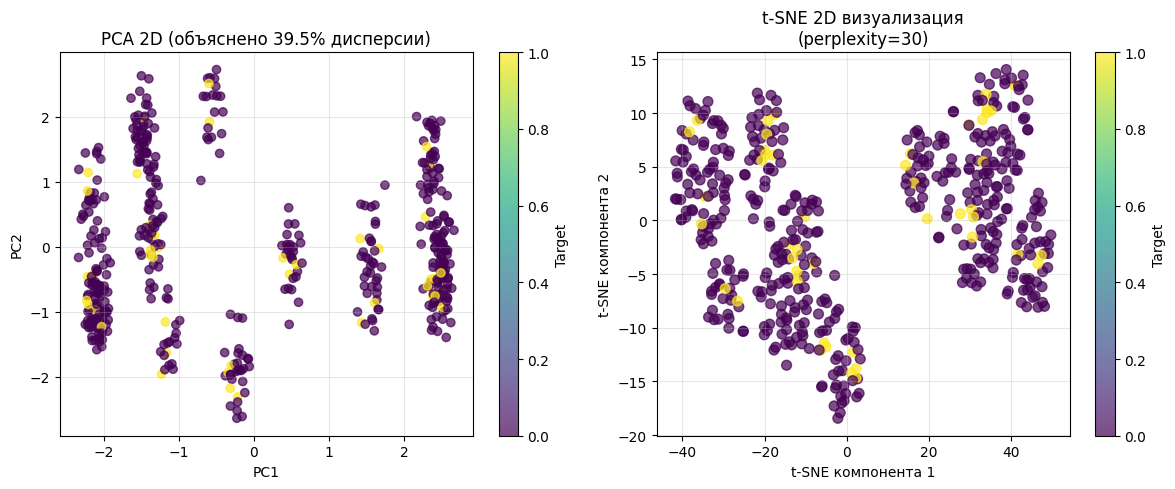


Сравнение методов понижения размерности:
PCA:
  - Линейный метод, сохраняет глобальную структуру
  - Объясненная дисперсия: 0.3954
  - Подходит для: предварительный анализ, отбор признаков

t-SNE:
  - Нелинейный метод, сохраняет локальную структуру
  - Подходит для: визуализация, выявление кластеров

Рекомендации:
  • Для анализа: использовать 10 PCA компонент
  • Для визуализации: использовать t-SNE или 2D PCA
✅ Данные с пониженной размерностью готовы для использования
   X_pca_reduced: (500, 10)
   X_tsne_reduced: (500, 2)

Анализ данных завершен!
Данные готовы для построения моделей машинного обучения


In [6]:
### 6. Понижение размерности данных

print("Понижение размерности данных:")
print("="*50)

# Проверка необходимости понижения размерности
print(f"Текущая размерность данных: {X_scaled.shape}")
n_features = X_scaled.shape[1]

if n_features > 10:
    print(f"Количество признаков ({n_features}) достаточно велико для применения понижения размерности")
    need_dimensionality_reduction = True
else:
    print(f"Количество признаков ({n_features}) небольшое, понижение размерности может не требоваться")
    need_dimensionality_reduction = False

if need_dimensionality_reduction:
    print("\n🔄 Применяем методы понижения размерности")

    # 1. PCA (Principal Component Analysis)
    print("\n1. PCA - Главный компонентный анализ:")
    from sklearn.decomposition import PCA

    # Определяем оптимальное количество компонент (оставляем 95% дисперсии)
    pca_full = PCA()
    pca_full.fit(X_scaled)
    
    cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)
    
    print("Детальный анализ кумулятивной дисперсии:")
    for i, cum_var in enumerate(cumulative_variance):
        print(f"PC{i+1}: {cum_var:.3f} {'✓' if cum_var >= 0.95 else ''}")
    
    n_components_95 = np.where(cumulative_variance >= 0.95)[0][0] + 1
    print(f"\nПервый индекс >= 0.95: {np.where(cumulative_variance >= 0.95)[0][0]}")
    print(f"n_components_95: {n_components_95}")
    
    # Проверяем, действительно ли достигаем 95%
    pca_optimal = PCA(n_components=n_components_95)
    X_pca_optimal = pca_optimal.fit_transform(X_scaled)
    actual_variance = np.sum(pca_optimal.explained_variance_ratio_)
    print(f"Фактическая дисперсия с {n_components_95} компонентами: {actual_variance:.4f}")
    print(f"PCA с {n_components_95} компонентами: Размерность {X_pca_optimal.shape}")
    print(f"Объясненная дисперсия: {pca_optimal.explained_variance_ratio_}")
    print(f"Суммарная дисперсия: {np.sum(pca_optimal.explained_variance_ratio_):.4f}")

    # Применяем PCA с 2 компонентами для визуализации
    pca_2d = PCA(n_components=2)
    X_pca_2d = pca_2d.fit_transform(X_scaled)
    variance_2d = np.sum(pca_2d.explained_variance_ratio_)
    X_pca_2_reduced = pd.DataFrame(
        X_pca_2d, 
        columns=[f'PC{i+1}' for i in range(2)]
    )

    print(f"⚠️ Для визуализации используем 2 компоненты вместо {n_components_95} рекомендованных")
    print(f"⚠️ Сохраняется {variance_2d:.1%} дисперсии")
    # Визуализация PCA
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    scatter = plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1],
                        c=y, cmap='viridis', alpha=0.7)
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.title(f'PCA 2D (объяснено {variance_2d:.1%} дисперсии)')
    plt.colorbar(scatter, label='Target')
    plt.grid(True, alpha=0.3)

    # 2. t-SNE (t-Distributed Stochastic Neighbor Embedding)
    print("\n2. t-SNE - стохастическое вложение соседей с t-распределением:")
    from sklearn.manifold import TSNE

    # Применяем t-SNE для 2D визуализации
    tsne_2d = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
    X_tsne_2d = tsne_2d.fit_transform(X_scaled)
    

    print(f"t-SNE: Размерность снижена до {X_tsne_2d.shape}")

    # Визуализация t-SNE
    plt.subplot(1, 2, 2)
    scatter = plt.scatter(X_tsne_2d[:, 0], X_tsne_2d[:, 1],
                        c=y, cmap='viridis', alpha=0.7, s=50)
    plt.xlabel('t-SNE компонента 1')
    plt.ylabel('t-SNE компонента 2')
    plt.title('t-SNE 2D визуализация\n(perplexity=30)')
    plt.colorbar(scatter, label='Target')
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Сравнение методов визуализации
    print("\nСравнение методов понижения размерности:")
    print("PCA:")
    print(f"  - Линейный метод, сохраняет глобальную структуру")
    print(f"  - Объясненная дисперсия: {variance_2d:.4f}")
    print(f"  - Подходит для: предварительный анализ, отбор признаков")

    print("\nt-SNE:")
    print(f"  - Нелинейный метод, сохраняет локальную структуру")
    print(f"  - Подходит для: визуализация, выявление кластеров")

    print(f"\nРекомендации:")
    print(f"  • Для анализа: использовать {n_components_95} PCA компонент")
    print(f"  • Для визуализации: использовать t-SNE или 2D PCA")

    # Создание датасетов с пониженной размерностью для дальнейшего использования
    X_pca_reduced = pd.DataFrame(
        X_pca_optimal, 
        columns=[f'PC{i+1}' for i in range(n_components_95)]
    )
    X_tsne_reduced = pd.DataFrame(X_tsne_2d, columns=['TSNE1', 'TSNE2'])

    print("✅ Данные с пониженной размерностью готовы для использования")
    print(f"   X_pca_reduced: {X_pca_reduced.shape}")
    print(f"   X_tsne_reduced: {X_tsne_reduced.shape}")

else:
    print("✅ Понижение размерности не требуется")
    print("Данные уже имеют оптимальную размерность для анализа")

print("\n" + "="*50)
print("Анализ данных завершен!")
print("Данные готовы для построения моделей машинного обучения")


Кластеризация DBSCAN:
Подготовка данных для кластеризации:
Используем стандартизованные данные: (500, 12)
Применяем DBSCAN к исходным данным и данным с пониженной размерностью...

1. DBSCAN на данных с пониженной размерностью (PCA):

Подбор оптимальных параметров DBSCAN:
eps=0.05, min_samples=3: 38 кластеров, silhouette=0.5898
eps=0.05, min_samples=5: 4 кластеров, silhouette=0.6523
eps=0.1, min_samples=3: 37 кластеров, silhouette=0.3838
eps=0.1, min_samples=5: 12 кластеров, silhouette=0.6835
eps=0.1, min_samples=7: 13 кластеров, silhouette=0.5345
eps=0.1, min_samples=10: 3 кластеров, silhouette=0.8174
eps=0.15, min_samples=3: 23 кластеров, silhouette=0.4503
eps=0.15, min_samples=5: 16 кластеров, silhouette=0.5441
eps=0.15, min_samples=7: 11 кластеров, silhouette=0.6238
eps=0.15, min_samples=10: 9 кластеров, silhouette=0.7508
eps=0.15, min_samples=15: 4 кластеров, silhouette=0.5435
eps=0.2, min_samples=3: 14 кластеров, silhouette=0.1939
eps=0.2, min_samples=5: 13 кластеров, silhouette=0

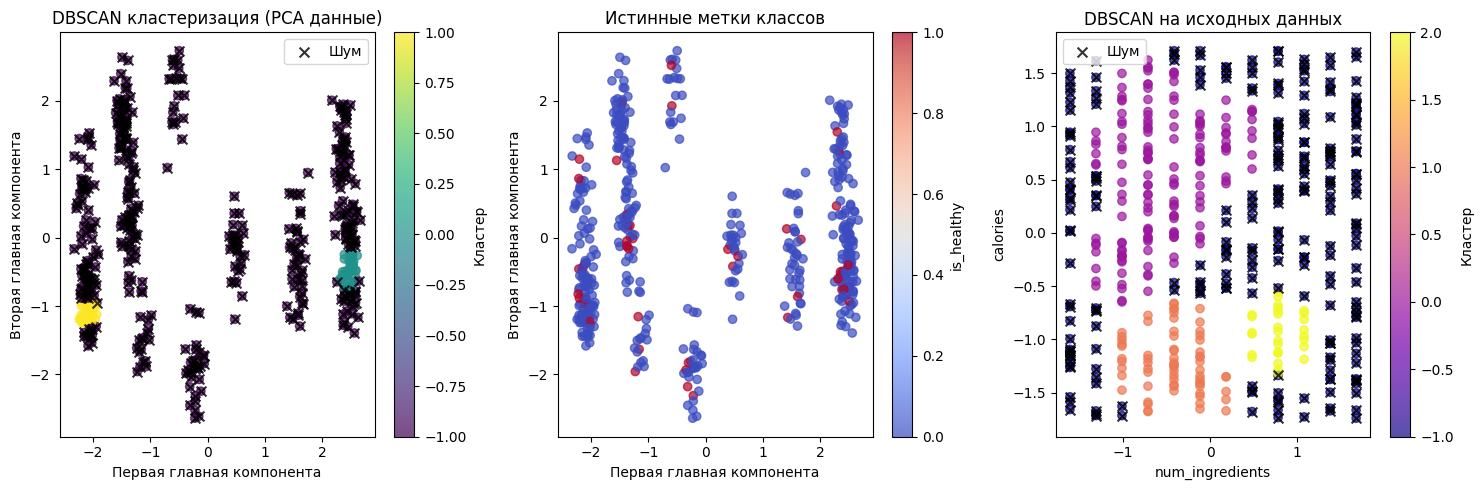


Анализ характеристик кластеров:

Кластер 0:
  Размер: 43 точек
  Центр кластера (средние координаты): PC1    2.476814
PC2   -0.471237
dtype: float64
  Стандартное отклонение: PC1    0.073687
PC2    0.157873
dtype: float64

Кластер 1:
  Размер: 31 точек
  Центр кластера (средние координаты): PC1   -2.091921
PC2   -1.110264
dtype: float64
  Стандартное отклонение: PC1    0.086326
PC2    0.105154
dtype: float64

Adjusted Rand Index (ARI): 0.0445
ARI показывает сходство между кластерами и истинными метками

Преимущества DBSCAN:
✅ Не требует заранее заданного количества кластеров
✅ Может находить кластеры произвольной формы
✅ Выявляет шумовые точки
✅ Не чувствителен к порядку точек

Недостатки DBSCAN:
⚠️  Требует подбора параметров eps и min_samples
⚠️  Плохо работает с кластерами сильно разной плотности
⚠️  Зависит от выбора метрики расстояния

Анализ кластеризации DBSCAN завершен!
Кластеризация позволяет выявить скрытые структуры в данных


In [7]:
### 7. Кластеризация DBSCAN

print("Кластеризация DBSCAN:")
print("="*50)

# Импорт необходимых библиотек для DBSCAN
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score, adjusted_rand_score
import numpy as np

# Подготовка данных для кластеризации
# Используем стандартизованные данные для лучшей работы DBSCAN
print("Подготовка данных для кластеризации:")
print(f"Используем стандартизованные данные: {X_scaled.shape}")

# Для демонстрации также применим DBSCAN к данным с пониженной размерностью
print("Применяем DBSCAN к исходным данным и данным с пониженной размерностью...")

# 1. DBSCAN на исходных данных (2D для визуализации)
print("\n1. DBSCAN на данных с пониженной размерностью (PCA):")
X_dbscan = X_pca_2_reduced.copy()  # Используем PCA для 2D визуализации

# Параметры DBSCAN (нужно подобрать экспериментально)
# Расширяем диапазон для лучшего поиска оптимальных параметров
eps_values = [0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
min_samples_values = [3, 5, 7, 10, 15, 20, 25, 30]

best_score = -1
best_params = {}

print("\nПодбор оптимальных параметров DBSCAN:")
for eps in eps_values:
    for min_samples in min_samples_values:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples, metric='euclidean')
        labels = dbscan.fit_predict(X_dbscan)

        # Исключаем шумовые точки (-1) для расчета silhouette score
        unique_labels = np.unique(labels)
        n_clusters_found = len(unique_labels[unique_labels != -1])
        
        if n_clusters_found > 1:
            mask = labels != -1
            if np.sum(mask) > 1:  # Убедимся, что есть хотя бы 2 точки для расчета
                try:
                    score = silhouette_score(X_dbscan[mask], labels[mask])
                    print(f"eps={eps}, min_samples={min_samples}: {n_clusters_found} кластеров, silhouette={score:.4f}")

                    if score > best_score:
                        best_score = score
                        best_params = {'eps': eps, 'min_samples': min_samples}
                except ValueError:
                    continue

if best_params:
    print(f"\nЛучшие параметры: {best_params} с silhouette score = {best_score:.4f}")

    # Применяем DBSCAN с оптимальными параметрами
    optimal_eps = best_params['eps']
    optimal_min_samples = best_params['min_samples']

    dbscan_optimal = DBSCAN(eps=optimal_eps, min_samples=optimal_min_samples, metric='euclidean')
    labels_optimal = dbscan_optimal.fit_predict(X_dbscan)

    # Визуализация результатов кластеризации
    plt.figure(figsize=(15, 5))

    # График 1: Результаты DBSCAN на данных PCA
    plt.subplot(1, 3, 1)
    
    # Преобразуем в numpy array для индексации
    if hasattr(X_dbscan, 'iloc'):
        x_coords = X_dbscan.iloc[:, 0]
        y_coords = X_dbscan.iloc[:, 1]
    else:
        x_coords = X_dbscan[:, 0]
        y_coords = X_dbscan[:, 1]
    
    scatter = plt.scatter(x_coords, y_coords,
                        c=labels_optimal, cmap='viridis', alpha=0.7)
    plt.xlabel('Первая главная компонента')
    plt.ylabel('Вторая главная компонента')
    plt.title('DBSCAN кластеризация (PCA данные)')
    plt.colorbar(scatter, label='Кластер')

    # Подсвечиваем шумовые точки
    noise_mask = labels_optimal == -1
    if np.sum(noise_mask) > 0:
        plt.scatter(x_coords[noise_mask], y_coords[noise_mask],
                c='black', marker='x', s=50, alpha=0.8, label='Шум')
    plt.legend()

    # График 2: Сравнение с истинными метками (если есть)
    plt.subplot(1, 3, 2)
    scatter_true = plt.scatter(x_coords, y_coords,
                            c=y, cmap='coolwarm', alpha=0.7)
    plt.xlabel('Первая главная компонента')
    plt.ylabel('Вторая главная компонента')
    plt.title('Истинные метки классов')
    plt.colorbar(scatter_true, label='is_healthy')

    # График 3: DBSCAN на исходных данных (первые 2 признака для визуализации)
    plt.subplot(1, 3, 3)
    
    # Берем первые 2 признака для визуализации
    if hasattr(X_scaled, 'iloc'):
        X_2d = X_scaled.iloc[:, :2].values
        feature_names = X_scaled.columns[:2]
    else:
        X_2d = X_scaled[:, :2]
        feature_names = ['Feature 1', 'Feature 2']

    dbscan_2d = DBSCAN(eps=optimal_eps * 2, min_samples=optimal_min_samples)
    labels_2d = dbscan_2d.fit_predict(X_2d)

    scatter_2d = plt.scatter(X_2d[:, 0], X_2d[:, 1],
                            c=labels_2d, cmap='plasma', alpha=0.7)
    plt.xlabel(feature_names[0])
    plt.ylabel(feature_names[1])
    plt.title('DBSCAN на исходных данных')
    plt.colorbar(scatter_2d, label='Кластер')

    # Подсвечиваем шумовые точки
    noise_mask_2d = labels_2d == -1
    if np.sum(noise_mask_2d) > 0:
        plt.scatter(X_2d[noise_mask_2d, 0], X_2d[noise_mask_2d, 1],
                c='black', marker='x', s=50, alpha=0.8, label='Шум')
    plt.legend()

    plt.tight_layout()
    plt.show()

    # Анализ характеристик кластеров
    print("\nАнализ характеристик кластеров:")
    unique_labels = np.unique(labels_optimal)
    unique_labels = unique_labels[unique_labels != -1]  # Исключаем шум

    for label in unique_labels:
        cluster_mask = labels_optimal == label
        cluster_points = X_dbscan[cluster_mask]
        print(f"\nКластер {label}:")
        print(f"  Размер: {len(cluster_points)} точек")
        print(f"  Центр кластера (средние координаты): {cluster_points.mean(axis=0)}")
        print(f"  Стандартное отклонение: {cluster_points.std(axis=0)}")

    # Сравнение с истинными метками (если применимо)
    if 'y' in locals() and len(unique_labels) == len(np.unique(y)):
        try:
            ari_score = adjusted_rand_score(y, labels_optimal)
            print(f"\nAdjusted Rand Index (ARI): {ari_score:.4f}")
            print("ARI показывает сходство между кластерами и истинными метками")
        except:
            print("\nНевозможно вычислить ARI - проблема с метками")
    else:
        print(f"\nКоличество кластеров DBSCAN ({len(unique_labels)}) != количеству классов ({len(np.unique(y)) if 'y' in locals() else 'N/A'})")

else:
    print("Не удалось найти подходящие параметры для DBSCAN")

print("\nПреимущества DBSCAN:")
print("✅ Не требует заранее заданного количества кластеров")
print("✅ Может находить кластеры произвольной формы")
print("✅ Выявляет шумовые точки")
print("✅ Не чувствителен к порядку точек")

print("\nНедостатки DBSCAN:")
print("⚠️  Требует подбора параметров eps и min_samples")
print("⚠️  Плохо работает с кластерами сильно разной плотности")
print("⚠️  Зависит от выбора метрики расстояния")

print("\n" + "="*50)
print("Анализ кластеризации DBSCAN завершен!")
print("Кластеризация позволяет выявить скрытые структуры в данных")

Иерархическая кластеризация:
Подготовка данных для иерархической кластеризации:
Используем стандартизованные данные: (500, 12)

Подбор оптимальных параметров иерархической кластеризации:
n_clusters=2, linkage=ward: silhouette=0.5638
n_clusters=2, linkage=complete: silhouette=0.5590
n_clusters=2, linkage=average: silhouette=0.5513
n_clusters=2, linkage=single: silhouette=0.5513
n_clusters=3, linkage=ward: silhouette=0.5431
n_clusters=3, linkage=complete: silhouette=0.5475
n_clusters=3, linkage=average: silhouette=0.5024
n_clusters=3, linkage=single: silhouette=0.4518
n_clusters=4, linkage=ward: silhouette=0.4685
n_clusters=4, linkage=complete: silhouette=0.4456
n_clusters=4, linkage=average: silhouette=0.5032
n_clusters=4, linkage=single: silhouette=0.3703
n_clusters=5, linkage=ward: silhouette=0.4629
n_clusters=5, linkage=complete: silhouette=0.4481
n_clusters=5, linkage=average: silhouette=0.4574
n_clusters=5, linkage=single: silhouette=0.3290
n_clusters=6, linkage=ward: silhouette=0.

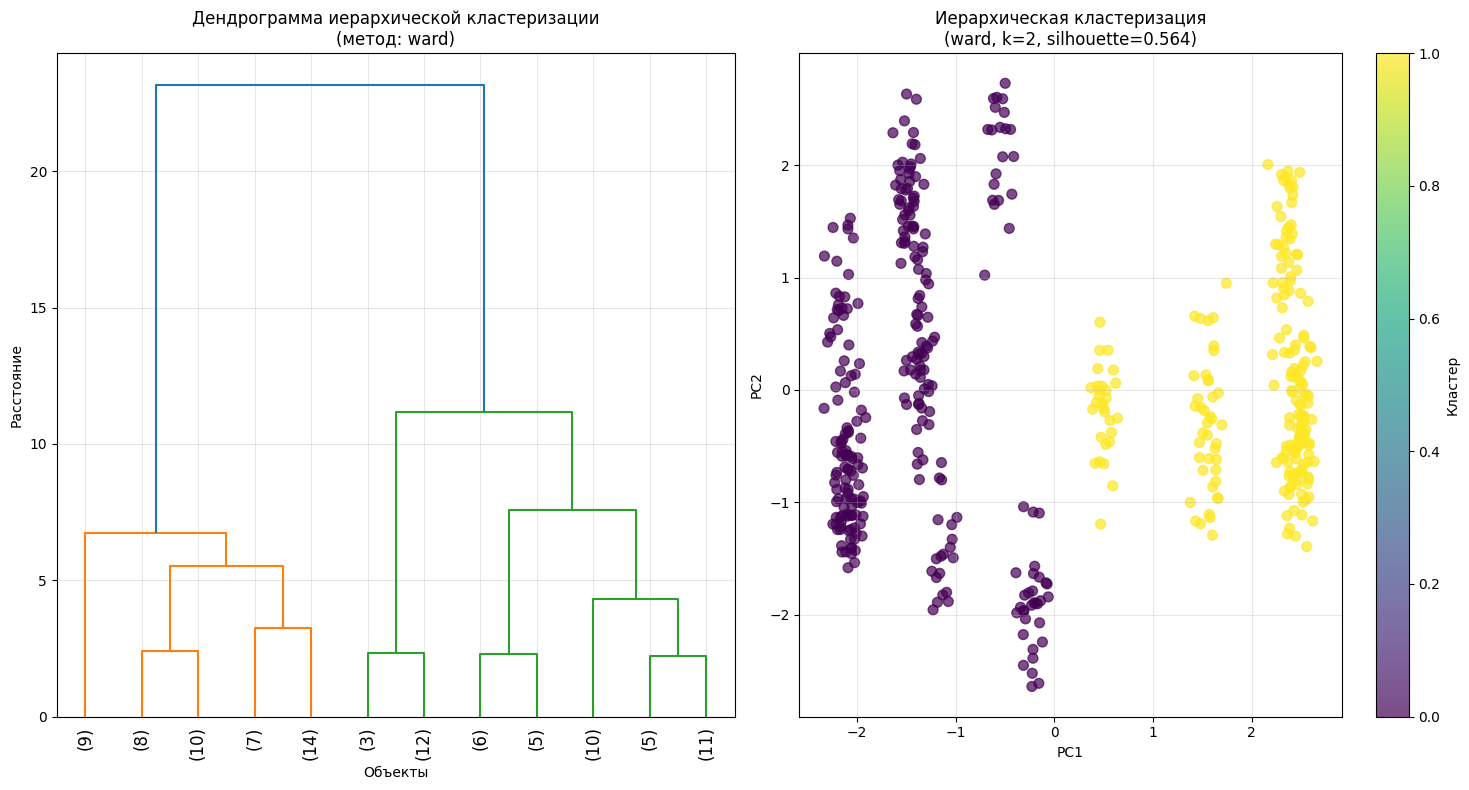


3. Сравнение методов связи:
Метод ward: silhouette = 0.5638
Метод complete: silhouette = 0.5590
Метод average: silhouette = 0.5513
Метод single: silhouette = 0.5513


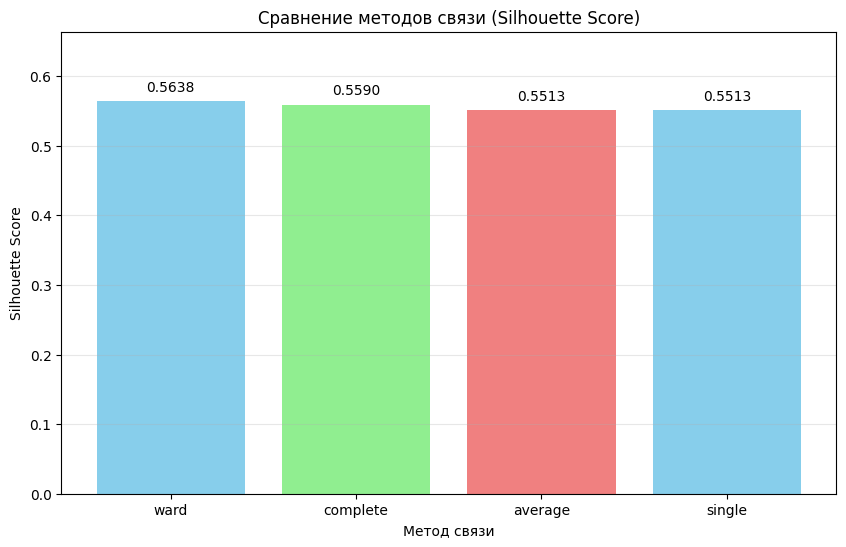


4. Анализ характеристик кластеров:

Кластер 0:
  Размер: 288 точек (57.6%)
  Центр кластера: [-1.4751  0.0023]
  Стандартное отклонение: [0.6422 1.3605]
  Среднее расстояние до центра: 1.3402

Кластер 1:
  Размер: 212 точек (42.4%)
  Центр кластера: [ 2.0039 -0.0031]
  Стандартное отклонение: [0.695  0.8137]
  Среднее расстояние до центра: 0.9748

Adjusted Rand Index (ARI): -0.0025
Интерпретация: слабое соответствие с истинными метками

5. Анализ стабильности кластеризации:
Silhouette scores на подвыборках: ['0.5197', '0.5506', '0.5691']
Средний score: 0.5465 (±0.0204)

Преимущества иерархической кластеризации:
✅ Создает иерархию кластеров (дендрограмма)
✅ Не требует заранее заданного количества кластеров
✅ Легко интерпретировать результаты
✅ Подходит для небольших датасетов

Недостатки иерархической кластеризации:
⚠️  Высокая вычислительная сложность (O(n²) или O(n³))
⚠️  Не подходит для больших датасетов
⚠️  Трудно исправить ошибки объединения/разбиения
⚠️  Чувствительность к выброс

In [8]:
### 8. Иерархическая кластеризация

print("Иерархическая кластеризация:")
print("="*50)

# Импорт необходимых библиотек для иерархической кластеризации
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist
from sklearn.metrics import silhouette_score, adjusted_rand_score
import numpy as np
import matplotlib.pyplot as plt

# Подготовка данных для кластеризации
print("Подготовка данных для иерархической кластеризации:")
print(f"Используем стандартизованные данные: {X_scaled.shape}")

# Для демонстрации используем PCA данные или исходные стандартизованные
X_hierarchical = X_pca_2_reduced.copy()

# Параметры для экспериментов
n_clusters_range = [2, 3, 4, 5, 6]
linkage_methods = ['ward', 'complete', 'average', 'single']

best_score = -1
best_params = {}

print("\nПодбор оптимальных параметров иерархической кластеризации:")
for n_clusters in n_clusters_range:
    for method in linkage_methods:
        try:
            # Создаем модель с текущими параметрами
            hierarchical = AgglomerativeClustering(
                n_clusters=n_clusters, 
                linkage=method, 
                metric='euclidean' if method == 'ward' else 'euclidean'
            )
            labels = hierarchical.fit_predict(X_hierarchical)

            # Оцениваем качество только если есть несколько кластеров
            if len(np.unique(labels)) > 1:
                score = silhouette_score(X_hierarchical, labels)
                print(f"n_clusters={n_clusters}, linkage={method}: silhouette={score:.4f}")

                if score > best_score:
                    best_score = score
                    best_params = {'n_clusters': n_clusters, 'linkage': method}
        except Exception as e:
            print(f"Ошибка для n_clusters={n_clusters}, linkage={method}: {e}")

print(f"\nЛучшие параметры: {best_params} с silhouette score = {best_score:.4f}")

# Применяем иерархическую кластеризацию с оптимальными параметрами
optimal_n_clusters = best_params['n_clusters']
optimal_linkage = best_params['linkage']

hierarchical_optimal = AgglomerativeClustering(
    n_clusters=optimal_n_clusters, 
    linkage=optimal_linkage
)
labels_hierarchical = hierarchical_optimal.fit_predict(X_hierarchical)

# Анализ результатов
n_clusters_found = len(np.unique(labels_hierarchical))
silhouette_avg = silhouette_score(X_hierarchical, labels_hierarchical)

print("\nРезультаты иерархической кластеризации:")
print(f"Количество кластеров: {n_clusters_found}")
print(f"Метод связи: {optimal_linkage}")
print(f"Silhouette Score: {silhouette_avg:.4f}")

# Анализ размеров кластеров
unique_labels, counts = np.unique(labels_hierarchical, return_counts=True)
print("\nРазмеры кластеров:")
for label, count in zip(unique_labels, counts):
    print(f"  Кластер {label}: {count} точек ({count/len(labels_hierarchical)*100:.1f}%)")

# 2. Построение дендрограммы
print("\n2. Построение дендрограммы:")
plt.figure(figsize=(15, 8))

# Для построения дендрограммы используем только подвыборку данных для производительности
sample_size = min(100, len(X_hierarchical))
np.random.seed(42)

if hasattr(X_hierarchical, 'iloc'):
    # Если это DataFrame
    sample_indices = np.random.choice(len(X_hierarchical), size=sample_size, replace=False)
    X_sample = X_hierarchical.iloc[sample_indices].values
else:
    # Если это numpy array
    sample_indices = np.random.choice(len(X_hierarchical), size=sample_size, replace=False)
    X_sample = X_hierarchical[sample_indices]

try:
    # Вычисляем матрицу связей
    Z = linkage(X_sample, method=optimal_linkage, metric='euclidean')

    # Строим дендрограмму
    plt.subplot(1, 2, 1)
    dendrogram(Z, truncate_mode='lastp', p=min(12, sample_size), 
               show_leaf_counts=True, leaf_rotation=90)
    plt.title(f'Дендрограмма иерархической кластеризации\n(метод: {optimal_linkage})')
    plt.xlabel('Объекты')
    plt.ylabel('Расстояние')
    plt.grid(True, alpha=0.3)
except Exception as e:
    print(f"Ошибка при построении дендрограммы: {e}")
    plt.subplot(1, 2, 1)
    plt.text(0.5, 0.5, 'Ошибка построения дендрограммы', 
             ha='center', va='center', transform=plt.gca().transAxes)
    plt.title('Дендрограмма недоступна')

# 3. Визуализация результатов кластеризации
plt.subplot(1, 2, 2)

if hasattr(X_hierarchical, 'iloc'):
    # Для DataFrame
    x_data = X_hierarchical.iloc[:, 0]
    y_data = X_hierarchical.iloc[:, 1]
    x_label = X_hierarchical.columns[0] if hasattr(X_hierarchical, 'columns') else 'Component 1'
    y_label = X_hierarchical.columns[1] if hasattr(X_hierarchical, 'columns') else 'Component 2'
else:
    # Для numpy array
    x_data = X_hierarchical[:, 0]
    y_data = X_hierarchical[:, 1]
    x_label = 'Component 1'
    y_label = 'Component 2'

scatter = plt.scatter(x_data, y_data, c=labels_hierarchical, 
                     cmap='viridis', alpha=0.7, s=50)
plt.xlabel(x_label)
plt.ylabel(y_label)
plt.title(f'Иерархическая кластеризация\n({optimal_linkage}, k={optimal_n_clusters}, silhouette={silhouette_avg:.3f})')
plt.colorbar(scatter, label='Кластер')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 4. Сравнение различных методов связи
print("\n3. Сравнение методов связи:")

methods_comparison = {}
n_clusters_demo = optimal_n_clusters  # Используем оптимальное количество кластеров

for method in ['ward', 'complete', 'average', 'single']:
    try:
        hierarchical_method = AgglomerativeClustering(
            n_clusters=n_clusters_demo, 
            linkage=method,
            metric='euclidean'
        )
        labels_method = hierarchical_method.fit_predict(X_hierarchical)

        # Оцениваем качество
        if len(np.unique(labels_method)) > 1:
            score = silhouette_score(X_hierarchical, labels_method)
            methods_comparison[method] = score
            print(f"Метод {method}: silhouette = {score:.4f}")
    except Exception as e:
        print(f"Ошибка для метода {method}: {e}")

# Визуализация сравнения методов
if methods_comparison:
    plt.figure(figsize=(10, 6))
    methods = list(methods_comparison.keys())
    scores = list(methods_comparison.values())
    
    colors = ['skyblue', 'lightgreen', 'lightcoral']
    bars = plt.bar(methods, scores, color=colors[:len(methods)])
    
    plt.title('Сравнение методов связи (Silhouette Score)')
    plt.ylabel('Silhouette Score')
    plt.xlabel('Метод связи')
    plt.ylim(0, max(scores) + 0.1)
    
    # Добавляем значения на столбцы
    for bar, score in zip(bars, scores):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{score:.4f}', ha='center', va='bottom')
    
    plt.grid(True, alpha=0.3, axis='y')
    plt.show()

# 5. Детальный анализ характеристик кластеров
print("\n4. Анализ характеристик кластеров:")

if hasattr(X_hierarchical, 'iloc'):
    # Для DataFrame
    X_array = X_hierarchical.values
else:
    # Для numpy array
    X_array = X_hierarchical

for label in unique_labels:
    cluster_mask = labels_hierarchical == label
    cluster_points = X_array[cluster_mask]
    
    print(f"\nКластер {label}:")
    print(f"  Размер: {len(cluster_points)} точек ({np.sum(cluster_mask)/len(labels_hierarchical)*100:.1f}%)")
    print(f"  Центр кластера: {np.mean(cluster_points, axis=0).round(4)}")
    print(f"  Стандартное отклонение: {np.std(cluster_points, axis=0).round(4)}")
    
    # Расстояние до центра кластера
    cluster_center = np.mean(cluster_points, axis=0)
    distances = np.linalg.norm(cluster_points - cluster_center, axis=1)
    print(f"  Среднее расстояние до центра: {np.mean(distances):.4f}")

# 6. Сравнение с истинными метками (если они есть)
if 'y' in locals() or 'y' in globals():
    try:
        ari_score = adjusted_rand_score(y, labels_hierarchical)
        print(f"\nAdjusted Rand Index (ARI): {ari_score:.4f}")
        
        # Интерпретация ARI
        if ari_score > 0.9:
            interpretation = "отличное соответствие"
        elif ari_score > 0.7:
            interpretation = "хорошее соответствие"
        elif ari_score > 0.5:
            interpretation = "умеренное соответствие"
        else:
            interpretation = "слабое соответствие"
            
        print(f"Интерпретация: {interpretation} с истинными метками")
    except Exception as e:
        print(f"\nНе удалось вычислить ARI: {e}")

# 7. Анализ стабильности кластеризации
print("\n5. Анализ стабильности кластеризации:")

# Проверяем с разными random states для подвыборки
stability_scores = []
for i in range(3):
    try:
        # Берем подвыборку
        sample_size = min(200, len(X_hierarchical))
        sample_indices = np.random.choice(len(X_hierarchical), size=sample_size, replace=False)
        
        if hasattr(X_hierarchical, 'iloc'):
            X_sample_test = X_hierarchical.iloc[sample_indices].values
        else:
            X_sample_test = X_hierarchical[sample_indices]
        
        # Кластеризуем подвыборку
        hierarchical_sample = AgglomerativeClustering(
            n_clusters=optimal_n_clusters, 
            linkage=optimal_linkage
        )
        labels_sample = hierarchical_sample.fit_predict(X_sample_test)
        
        if len(np.unique(labels_sample)) > 1:
            score = silhouette_score(X_sample_test, labels_sample)
            stability_scores.append(score)
    except Exception as e:
        print(f"Ошибка в итерации {i}: {e}")

if stability_scores:
    print(f"Silhouette scores на подвыборках: {[f'{s:.4f}' for s in stability_scores]}")
    print(f"Средний score: {np.mean(stability_scores):.4f} (±{np.std(stability_scores):.4f})")

print("\n" + "="*50)
print("Преимущества иерархической кластеризации:")
print("✅ Создает иерархию кластеров (дендрограмма)")
print("✅ Не требует заранее заданного количества кластеров")
print("✅ Легко интерпретировать результаты")
print("✅ Подходит для небольших датасетов")

print("\nНедостатки иерархической кластеризации:")
print("⚠️  Высокая вычислительная сложность (O(n²) или O(n³))")
print("⚠️  Не подходит для больших датасетов")
print("⚠️  Трудно исправить ошибки объединения/разбиения")
print("⚠️  Чувствительность к выбросам")

print("\nМетоды связи:")
print("• ward - минимизирует дисперсию внутри кластеров (только с евклидовой метрикой)")
print("• complete - использует максимальное расстояние между кластерами")
print("• average - использует среднее расстояние между кластерами")
print("• single - использует минимальное расстояние между кластерами")

print("\n" + "="*50)
print("Анализ иерархической кластеризации завершен!")
print(f"Лучшая конфигурация: {optimal_n_clusters} кластеров, метод '{optimal_linkage}'")
print(f"Качество кластеризации: Silhouette Score = {best_score:.4f}")

K-means кластеризация:
Подготовка данных для K-means кластеризации:
Используем стандартизованные данные: (500, 12)
Применяем K-means к данным с пониженной размерностью...

1. Определение оптимального количества кластеров:
Вычисляем инерцию и silhouette score для разных значений k...


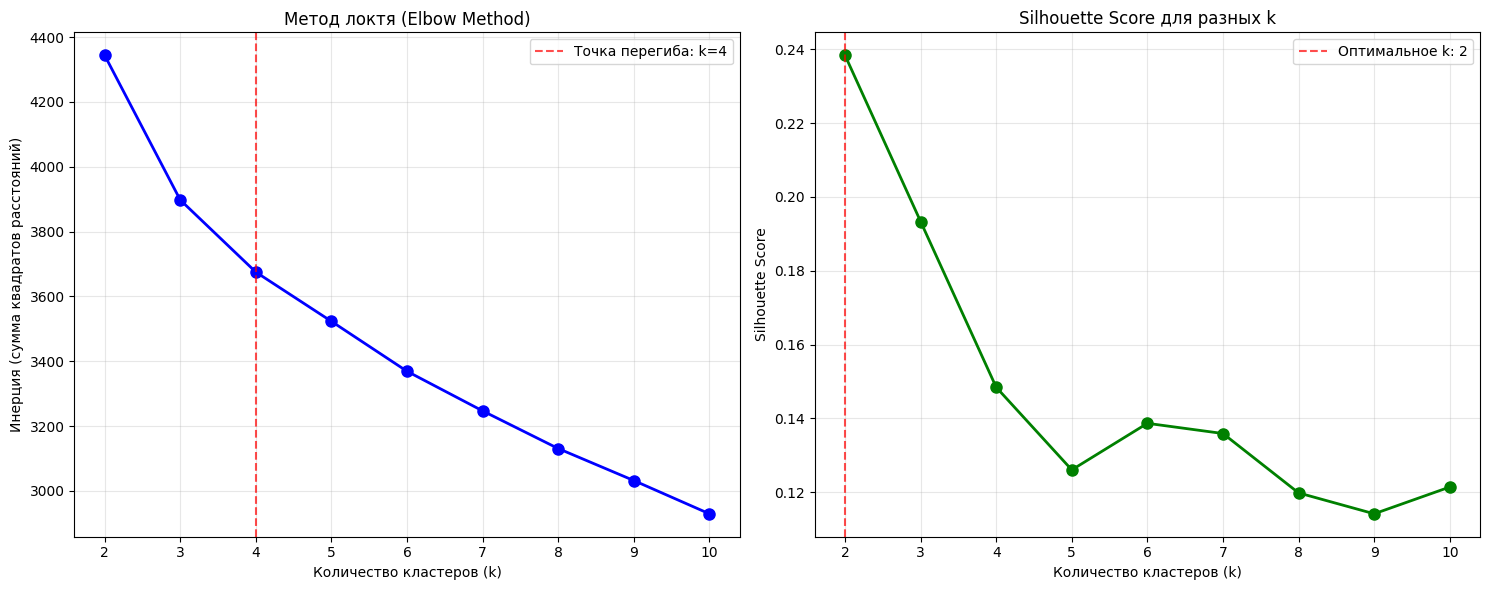

Оптимальное количество кластеров по silhouette score: 2

Выбрано оптимальное количество кластеров: 2

2. Применение K-means с k=2:
Результаты K-means:
Количество кластеров: 2
Инерция (сумма квадратов расстояний): 4343.7111
Средний silhouette score: 0.2384


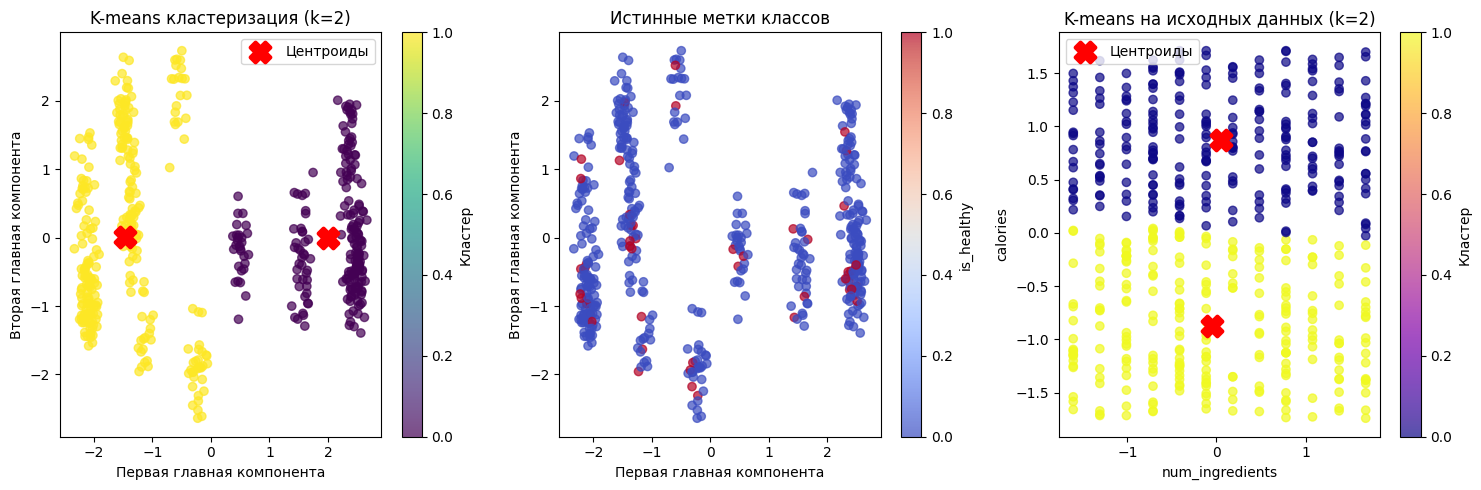


3. Анализ характеристик кластеров:

Кластер 0:
  Размер: 212 точек
  Центр кластера (средние координаты): [ 2.00392682e+00 -3.10502004e-03 -1.79916453e-03 -4.96135324e-03
  3.05476908e-02 -2.20554573e-02  1.38883562e-02 -3.59841937e-02
 -1.26645618e-01 -5.87253737e-02]
  Стандартное отклонение: [0.69661226 0.81563709 1.06892427 1.01075725 1.01464727 0.95534175
 0.93080838 0.95777416 0.85411244 0.64558775]

Кластер 1:
  Размер: 288 точек
  Центр кластера (средние координаты): [-1.47511279e+00  2.28563975e-03  1.32438500e-03  3.65210724e-03
 -2.24864946e-02  1.62352672e-02 -1.02233733e-02  2.64883648e-02
  9.32252463e-02  4.32284001e-02]
  Стандартное отклонение: [0.64333622 1.36285204 1.02922795 1.03374972 0.9796915  1.01560793
 0.9999443  0.92685508 0.74907229 0.55260881]

Центроиды кластеров:
Центроид кластера 0: [2.0039, -0.0031]
Центроид кластера 1: [-1.4751, 0.0023]

Adjusted Rand Index (ARI): -0.0025
ARI показывает сходство между кластерами и истинными метками

4. Сравнение разли

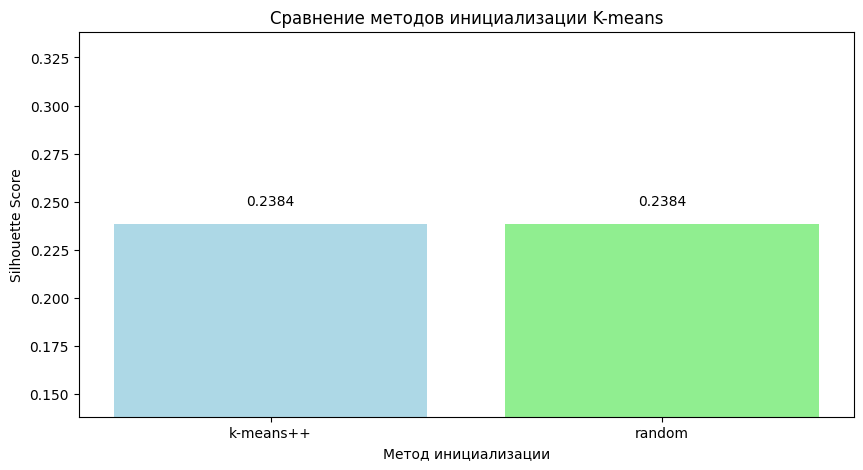


5. Проверка стабильности результатов:
Стабильность результатов (silhouette scores для 5 запусков): [0.23835194264286513, 0.23835194264286513, 0.23835194264286513, 0.23835194264286513, 0.23835194264286513]
Среднее значение: 0.2384
Стандартное отклонение: 0.0000

Преимущества K-means:
✅ Простой и понятный алгоритм
✅ Высокая скорость работы (O(n*k*t), где t - количество итераций)
✅ Гарантированная сходимость
✅ Легко интерпретировать результаты
✅ Работает с большими датасетами

Недостатки K-means:
⚠️  Требует заранее заданного количества кластеров
⚠️  Чувствителен к выбросам
⚠️  Зависит от начальной инициализации центроидов
⚠️  Предполагает сферическую форму кластеров
⚠️  Может сходиться к локальному минимуму

Методы инициализации:
• k-means++ - улучшенная инициализация (рекомендуется)
• random - случайная инициализация центроидов

Критерии качества:
• Инерция - сумма квадратов расстояний до центроидов (меньше = лучше)
• Silhouette score - насколько точки близки к своему кластеру vs други

In [12]:
### 9. K-means кластеризация

print("K-means кластеризация:")
print("="*50)

# Импорт необходимых библиотек для K-means
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score
import numpy as np

# Подготовка данных для кластеризации
print("Подготовка данных для K-means кластеризации:")
print(f"Используем стандартизованные данные: {X_scaled.shape}")

# Для демонстрации применим K-means к данным с пониженной размерностью
print("Применяем K-means к данным с пониженной размерностью...")
X_kmeans = X_pca_reduced.copy()  # Используем PCA для 2D визуализации

# 1. Определение оптимального количества кластеров
print("\n1. Определение оптимального количества кластеров:")

# Метод локтя (Elbow Method)
inertias = []
silhouette_scores = []
k_range = range(2, 11)

print("Вычисляем инерцию и silhouette score для разных значений k...")
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_kmeans)

    inertias.append(kmeans.inertia_)

    if len(np.unique(labels)) > 1:
            score = silhouette_score(X_kmeans, labels)
            silhouette_scores.append(score)
    else:
        silhouette_scores.append(-1)

# Визуализация метода локтя и силуэта
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# График метода локтя
ax1.plot(k_range, inertias, 'bo-', linewidth=2, markersize=8)
ax1.set_xlabel('Количество кластеров (k)')
ax1.set_ylabel('Инерция (сумма квадратов расстояний)')
ax1.set_title('Метод локтя (Elbow Method)')
ax1.grid(True, alpha=0.3)

# Добавляем вертикальную линию в точке перегиба
if len(inertias) > 3:
    # Находим точку перегиба простым способом
    diffs = np.diff(inertias)
    second_diffs = np.diff(diffs)
    elbow_point = np.argmax(second_diffs) + 2  # +2 из-за двойного дифференцирования
    ax1.axvline(x=k_range[elbow_point], color='red', linestyle='--', alpha=0.7, label=f'Точка перегиба: k={k_range[elbow_point]}')
    ax1.legend()

# График силуэта
ax2.plot(k_range, silhouette_scores, 'go-', linewidth=2, markersize=8)
ax2.set_xlabel('Количество кластеров (k)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score для разных k')
ax2.grid(True, alpha=0.3)

# Находим оптимальное k по максимуму силуэта
if max(silhouette_scores) > -1:
    optimal_k_silhouette = k_range[np.argmax(silhouette_scores)]
    ax2.axvline(x=optimal_k_silhouette, color='red', linestyle='--', alpha=0.7, label=f'Оптимальное k: {optimal_k_silhouette}')
    ax2.legend()

plt.tight_layout()
plt.show()

# Выбираем оптимальное количество кластеров
# Используем комбинацию метода локтя и силуэта
if max(silhouette_scores) > -1:
    optimal_k = optimal_k_silhouette
    print(f"Оптимальное количество кластеров по silhouette score: {optimal_k}")
else:
    # Если не удалось рассчитать силуэт, используем метод локтя
    if len(inertias) > 3:
        optimal_k = k_range[elbow_point]
        print(f"Оптимальное количество кластеров по методу локтя: {optimal_k}")
    else:
        optimal_k = 3  # значение по умолчанию
        print(f"Используем количество кластеров по умолчанию: {optimal_k}")

print(f"\nВыбрано оптимальное количество кластеров: {optimal_k}")

# 2. Применение K-means с оптимальным количеством кластеров
print(f"\n2. Применение K-means с k={optimal_k}:")

kmeans_optimal = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
labels_kmeans = kmeans_optimal.fit_predict(X_kmeans)

# Анализ результатов
n_clusters_found = len(np.unique(labels_kmeans))

print("Результаты K-means:")
print(f"Количество кластеров: {n_clusters_found}")
print(f"Инерция (сумма квадратов расстояний): {kmeans_optimal.inertia_:.4f}")

# Оцениваем качество кластеризации
if len(np.unique(labels_kmeans)) > 1:
        silhouette_avg = silhouette_score(X_kmeans, labels_kmeans)
        print(f"Средний silhouette score: {silhouette_avg:.4f}")
# 3. Визуализация результатов K-means
plt.figure(figsize=(15, 5))

# График 1: Результаты K-means на данных PCA
plt.subplot(1, 3, 1)
scatter = plt.scatter(X_kmeans.iloc[:, 0], X_kmeans.iloc[:, 1],
                    c=labels_kmeans, cmap='viridis', alpha=0.7)
plt.scatter(kmeans_optimal.cluster_centers_[:, 0], kmeans_optimal.cluster_centers_[:, 1],
        c='red', marker='X', s=200, linewidths=3, label='Центроиды')
plt.xlabel('Первая главная компонента')
plt.ylabel('Вторая главная компонента')
plt.title(f'K-means кластеризация (k={optimal_k})')
plt.colorbar(scatter, label='Кластер')
plt.legend()

# График 2: Сравнение с истинными метками
plt.subplot(1, 3, 2)
scatter_true = plt.scatter(X_kmeans.iloc[:, 0], X_kmeans.iloc[:, 1],
                        c=y, cmap='coolwarm', alpha=0.7)
plt.xlabel('Первая главная компонента')
plt.ylabel('Вторая главная компонента')
plt.title('Истинные метки классов')
plt.colorbar(scatter_true, label='is_healthy')

# График 3: K-means на исходных данных
plt.subplot(1, 3, 3)
X_2d = X_scaled.iloc[:, :2]  # Берем первые 2 признака для визуализации

kmeans_2d = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
labels_2d = kmeans_2d.fit_predict(X_2d)

scatter_2d = plt.scatter(X_2d.iloc[:, 0], X_2d.iloc[:, 1],
                        c=labels_2d, cmap='plasma', alpha=0.7)
plt.scatter(kmeans_2d.cluster_centers_[:, 0], kmeans_2d.cluster_centers_[:, 1],
        c='red', marker='X', s=200, linewidths=3, label='Центроиды')
plt.xlabel(X_scaled.columns[0])
plt.ylabel(X_scaled.columns[1])
plt.title(f'K-means на исходных данных (k={optimal_k})')
plt.colorbar(scatter_2d, label='Кластер')
plt.legend()

plt.tight_layout()
plt.show()

# 4. Анализ характеристик кластеров
print("\n3. Анализ характеристик кластеров:")
unique_labels = np.unique(labels_kmeans)

for label in unique_labels:
    cluster_points = X_kmeans[labels_kmeans == label]
    print(f"\nКластер {label}:")
    print(f"  Размер: {len(cluster_points)} точек")
    print(f"  Центр кластера (средние координаты): {cluster_points.mean().values}")
    print(f"  Стандартное отклонение: {cluster_points.std().values}")

# Центроиды кластеров
print("\nЦентроиды кластеров:")
centers = kmeans_optimal.cluster_centers_
for i, center in enumerate(centers):
    print(f"Центроид кластера {i}: [{center[0]:.4f}, {center[1]:.4f}]")

# 5. Сравнение с истинными метками
if n_clusters_found == len(np.unique(y)):
        ari_score = adjusted_rand_score(y, labels_kmeans)
        print(f"\nAdjusted Rand Index (ARI): {ari_score:.4f}")
        print("ARI показывает сходство между кластерами и истинными метками")
else:
    print(f"\nКоличество кластеров ({n_clusters_found}) != количеству классов ({len(np.unique(y))})")

# 6. Сравнение K-means с различными инициализациями
print("\n4. Сравнение различных методов инициализации:")

init_methods = ['k-means++', 'random']
init_comparison = {}

for init_method in init_methods:
    kmeans_init = KMeans(n_clusters=optimal_k, init=init_method, random_state=42, n_init=10)
    labels_init = kmeans_init.fit_predict(X_kmeans)

    if len(np.unique(labels_init)) > 1:
            score = silhouette_score(X_kmeans, labels_init)
            init_comparison[init_method] = score
            print(f"Метод инициализации '{init_method}': inertia = {kmeans_init.inertia_:.4f}, silhouette = {score:.4f}")
# Визуализация сравнения методов инициализации
plt.figure(figsize=(10, 5))
methods = list(init_comparison.keys())
scores = list(init_comparison.values())

plt.bar(methods, scores, color=['lightblue', 'lightgreen'])
plt.title('Сравнение методов инициализации K-means')
plt.ylabel('Silhouette Score')
plt.xlabel('Метод инициализации')

for i, (method, score) in enumerate(zip(methods, scores)):
    plt.text(i, score + 0.01, f'{score:.4f}', ha='center')

plt.ylim(min(scores) - 0.1, max(scores) + 0.1)
plt.show()

# 7. Проверка стабильности результатов
print("\n5. Проверка стабильности результатов:")

# Запускаем K-means несколько раз с разными случайными seed
stability_scores = []
for seed in range(5):
    kmeans_stab = KMeans(n_clusters=optimal_k, random_state=seed, n_init=10)
    labels_stab = kmeans_stab.fit_predict(X_kmeans)

    if len(np.unique(labels_stab)) > 1:
            score = silhouette_score(X_kmeans, labels_stab)
            stability_scores.append(score)
print(f"Стабильность результатов (silhouette scores для 5 запусков): {stability_scores}")
print(f"Среднее значение: {np.mean(stability_scores):.4f}")
print(f"Стандартное отклонение: {np.std(stability_scores):.4f}")

print("\nПреимущества K-means:")
print("✅ Простой и понятный алгоритм")
print("✅ Высокая скорость работы (O(n*k*t), где t - количество итераций)")
print("✅ Гарантированная сходимость")
print("✅ Легко интерпретировать результаты")
print("✅ Работает с большими датасетами")

print("\nНедостатки K-means:")
print("⚠️  Требует заранее заданного количества кластеров")
print("⚠️  Чувствителен к выбросам")
print("⚠️  Зависит от начальной инициализации центроидов")
print("⚠️  Предполагает сферическую форму кластеров")
print("⚠️  Может сходиться к локальному минимуму")

print("\nМетоды инициализации:")
print("• k-means++ - улучшенная инициализация (рекомендуется)")
print("• random - случайная инициализация центроидов")

print("\nКритерии качества:")
print("• Инерция - сумма квадратов расстояний до центроидов (меньше = лучше)")
print("• Silhouette score - насколько точки близки к своему кластеру vs другим кластерам")

print("\n" + "="*50)
print("Анализ K-means кластеризации завершен!")
print("K-means является одним из самых популярных алгоритмов кластеризации благодаря своей простоте и эффективности")